In [ ]:
# unsloth-zoo/tokenizer_utils.py

@torch.inference_mode
def add_new_tokens(
    model,
    tokenizer,
    new_tokens = [],
    method = "mean",
    interpolation = 0.5,
):
    """
    Smartly resizes the tokenizer and adds new tokens to the model.
    We also disregard untrained tokens by removing them from the mean calculation.
    """
    # All Unsloth Zoo code licensed under LGPLv3
    assert(isinstance(new_tokens, (list, tuple)))
    assert(len(new_tokens) > 0)
    assert(method == "mean" or method == "interpolation")
    assert(interpolation >= 0 and interpolation <= 1)

    # Check if tokens already exist
    overlapping_tokens = set(new_tokens) & set(tokenizer.vocab.keys())
    if len(overlapping_tokens) != 0:
        print(
            f"Unsloth: You're adding new_tokens = {new_tokens}\n"\
            f"There are tokens which are overlapping = {list(overlapping_tokens)}\n"\
            f"We shall safely ignore these overlapping tokens."
        )
        new_tokens = [x for x in new_tokens if x not in overlapping_tokens]
    pass

    # Get mean of trained tokens
    # mean_embedding, mean_lm_head = fix_untrained_tokens(model)

    # Weirdly be careful reserved tokens can pop out
    mean_embedding, mean_lm_head = mean_of_trained_tokens(model)
    mean_embedding = mean_embedding.to(torch.float32)
    mean_lm_head   = mean_lm_head  .to(torch.float32)

    # Get old lengths
    old_input_embedding  = model.get_input_embeddings ().weight
    old_output_embedding = model.get_output_embeddings().weight
    old_input_length  = old_input_embedding .shape[0]
    old_output_length = old_output_embedding.shape[0]
    old_config_size   = model.config.text_config.vocab_size

    # Check for tied weights as well
    is_tied = (old_input_embedding.data_ptr() == old_output_embedding.data_ptr()) \
        or (model.config.tie_word_embeddings)

    # Add tokens!
    old_length = len(tokenizer)
    tokenizer.add_tokens(new_tokens)
    # Also resizes lm_head as well!
    model.resize_token_embeddings(len(tokenizer))

    # If we use interpolation, we interpolate between the mean embeddings and
    # the Word2Vec sum of the other vectors
    embedding_matrix = model.get_input_embeddings ().weight
    lm_head_matrix   = model.get_output_embeddings().weight

    print("MODEL TEXT CONFIG : ", model.config.text_config.vocab_size)

    # Confirm sizes are correct
    if embedding_matrix.shape[0] != (old_input_length  + len(new_tokens)):
        raise RuntimeError(
            "Unsloth: Embedding matrix size did not get resized properly. Please file a bug report!"
        )
    if lm_head_matrix.shape[0]   != (old_output_length + len(new_tokens)):
        raise RuntimeError(
            "Unsloth: LM Head matrix size did not get resized properly. Please file a bug report!"
        )
    if model.config.text_config.vocab_size   != (old_config_size   + len(new_tokens)):
        raise RuntimeError(
            "Unsloth: Model's config vocab_size did not get resized properly. Please file a bug report!"
        )
    pass

    if method == "interpolation":
        print(
            "Unsloth: You are using interpolation to add new tokens.\n"\
            f"We shall set new tokens = mean(embeddings)*{1-interpolation} + mean(new_tokens)*{interpolation}"
        )
        for j, token in enumerate(new_tokens):
            input_ids = tokenizer(token, add_special_tokens = False).input_ids
            mean_embedding_token = embedding_matrix[input_ids].mean(axis = 0, dtype = torch.float32)
            mean_lm_head_token   = lm_head_matrix  [input_ids].mean(axis = 0, dtype = torch.float32)

            # Interpolate
            mean_embedding_token = mean_embedding*(1-interpolation) + mean_embedding_token*interpolation
            mean_lm_head_token   = mean_lm_head  *(1-interpolation) + mean_lm_head_token  *interpolation

            # Set the new vector
            embedding_matrix[old_length+j] = mean_embedding_token
            lm_head_matrix  [old_length+j] = mean_lm_head_token
        pass
    else:
        # Now set the new tokens to the mean!
        embedding_matrix[old_length:] = mean_embedding
        lm_head_matrix  [old_length:] = mean_lm_head
    pass

    # We set a flag to say we need to train embeddings
    internal_model = model
    while hasattr(internal_model, "model"):
        internal_model._need_to_train_embeddings = True
        internal_model = internal_model.model
    pass
    internal_model._need_to_train_embeddings = True

    # Fix up all vocab sizes
    current_model = model
    while hasattr(current_model, "model") and hasattr(current_model, "config"):
        if hasattr(current_model.config.text_config, "vocab_size"):
            current_model.config.text_config.update({"vocab_size" : len(tokenizer)})
        current_model = current_model.model
    if hasattr(current_model, "model") and hasattr(current_model, "config"):
        if hasattr(current_model.config.text_config, "vocab_size"):
            current_model.config.text_config.update({"vocab_size" : len(tokenizer)})
    pass

    # Must tie lm_head and embed_tokens if they are tied!
    # Otherwise error will occur on saving models ie use save_model
    if is_tied: model.tie_weights()

    # Clear deleted GPU items
    for _ in range(3):
        gc.collect()
        torch.cuda.empty_cache()
    return
pass

## Data Analysis

In [ ]:
import json

def get_data_from_json(file_path):
  with open(file_path, "r", encoding="utf-8") as f:
      data = json.load(f)
  return data


phonetic_token = get_data_from_json("phonetic_token.json") + ["[Ua]", "[ua]", "[ia]", "[@]",]
training_data = get_data_from_json("training_data.json")
validation_data = get_data_from_json("valid_data.json")

In [19]:
len(phonetic_token), len(training_data), len(validation_data)

(65, 9970, 1035)

In [21]:
# find the begging of <phonectic> tag and delete that data
training_data = [x for x in training_data if "<phonetic>" not in x]
validation_data = [x for x in validation_data if "<phonetic>" not in x]

In [20]:
sample_text = training_data[0]
for tag in phonetic_token:
    sample_text = sample_text.replace(tag, "")
print(sample_text.strip())

พอได้ยินเสียงระฆังข้างหลังเขา	เห็นผู้เฒ่าออกจากชะวากผา
ดูสรรพางค์ร่างกายแก่ชรา	แต่ผิวหน้านั้นละม้ายคล้ายทารก
ทรงเสื้อโขมพัสตรานุ่งผ้าขาว	ผมนั้นยาวย้อยสยายประปรายปรก
ถือไม้เท้าเนาวรัตน์พัดขนนก	ทำเดินงกงันมาแล้วพาที
ว่าดูราสามีนางผีเสื้อ	เป็นหน่อเนื้อกษัตริย์ชาติราชสีห์
อย่าเผาศพนางยักษ์ด้วยอัคคี	ภัยจะมีถึงกายให้วายปราณ


In [220]:
import re

threshold_a_rhythm_tag = 0.3

pattern = r'<r>(.+?)</r>'
phonetic_pattern = r'[\[a-zA-Z0-9]+\]'

result = []

for data in training_data:
    try:
        if "<phonetic>" in data:
            continue
        rhythm_tag = re.findall(pattern, data)
        rhythm_tag = re.findall(phonetic_pattern, "".join(rhythm_tag))

        a_rhythm_tag_count = 0
        for rhythm in rhythm_tag:
            if "a" in rhythm:
                a_rhythm_tag_count += 1
        
        if a_rhythm_tag_count / len(rhythm_tag) <= threshold_a_rhythm_tag:
            result.append(data)
            
    except Exception as e:
        print(f"Error processing data: {data}")
        print(len(rhythm_tag))
        
len(result)

3052

In [ ]:
import re
from collections import defaultdict

pattern = r'<r>(.+?)</r>'
phonetic_pattern = r'[\[a-zA-Z0-9]+\]'

result = defaultdict(lambda : defaultdict(int))
no_following = "nothing"

for data in training_data:
    try:
        if "<phonetic>" in data:
            continue
        rhythm_tag_list = re.findall(pattern, data)
        for rhythm_tag in rhythm_tag_list:
            normalized_rhythm_tag = re.findall(phonetic_pattern, rhythm_tag)
            if len(normalized_rhythm_tag) == 0:
                continue
            
            first_rhythm_tag = normalized_rhythm_tag[0]
            if len(normalized_rhythm_tag) == 1:
                result[first_rhythm_tag][no_following] = result[first_rhythm_tag].get(no_following, 0) + 1
            elif len(normalized_rhythm_tag) == 2:
                second_rhythm_tag = normalized_rhythm_tag[1]
                result[first_rhythm_tag][second_rhythm_tag] = result[first_rhythm_tag].get(second_rhythm_tag, 0) + 1
            else:
                print(f"Unexpected rhythm tag format: {normalized_rhythm_tag}")

    except Exception as e:
        print(f"Error : {e}")
        print(f"Error processing data: {data}")
        print(rhythm_tag_list)
        print(len(normalized_rhythm_tag))

result

defaultdict(<function __main__.<lambda>()>,
            {'[a]': defaultdict(int,
                         {'[w]': 3393,
                          'nothing': 20825,
                          '[n]': 19286,
                          '[j]': 29564,
                          '[N]': 7237,
                          '[m]': 4096,
                          '[k]': 3057,
                          '[t]': 4993,
                          '[p]': 3099}),
             '[o]': defaultdict(int,
                         {'[k]': 776,
                          '[n]': 4625,
                          '[N]': 3140,
                          '[t]': 1846,
                          '[p]': 1451,
                          'nothing': 382,
                          '[m]': 1823,
                          '[j]': 123}),
             '[i]': defaultdict(int,
                         {'nothing': 11725,
                          '[n]': 1690,
                          '[t]': 2160,
                          '[N]': 1464,
         

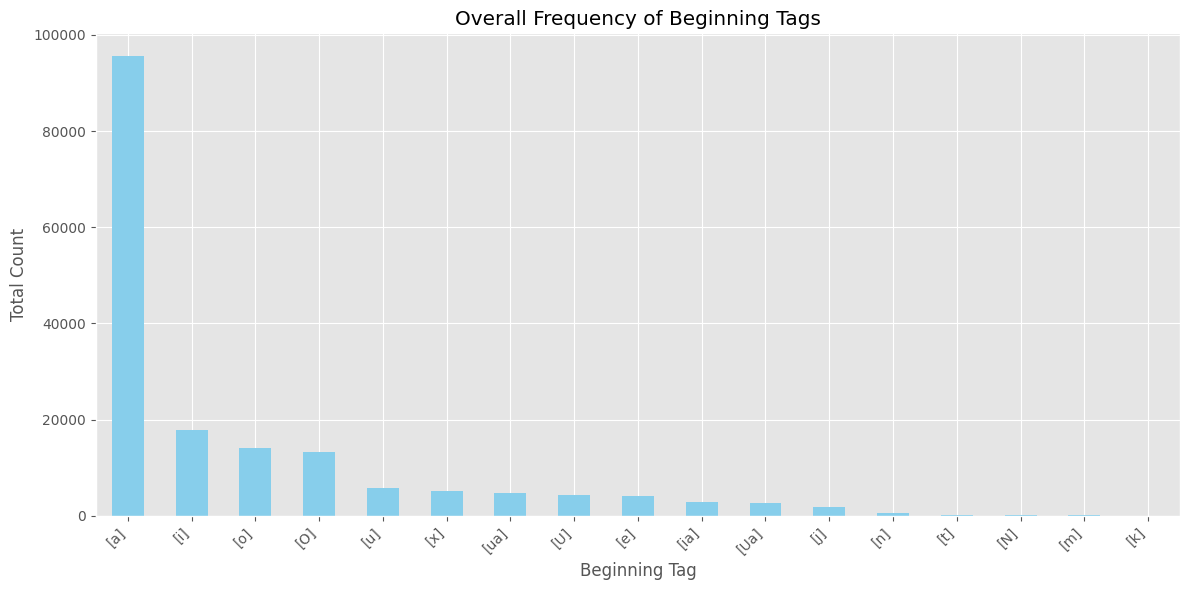

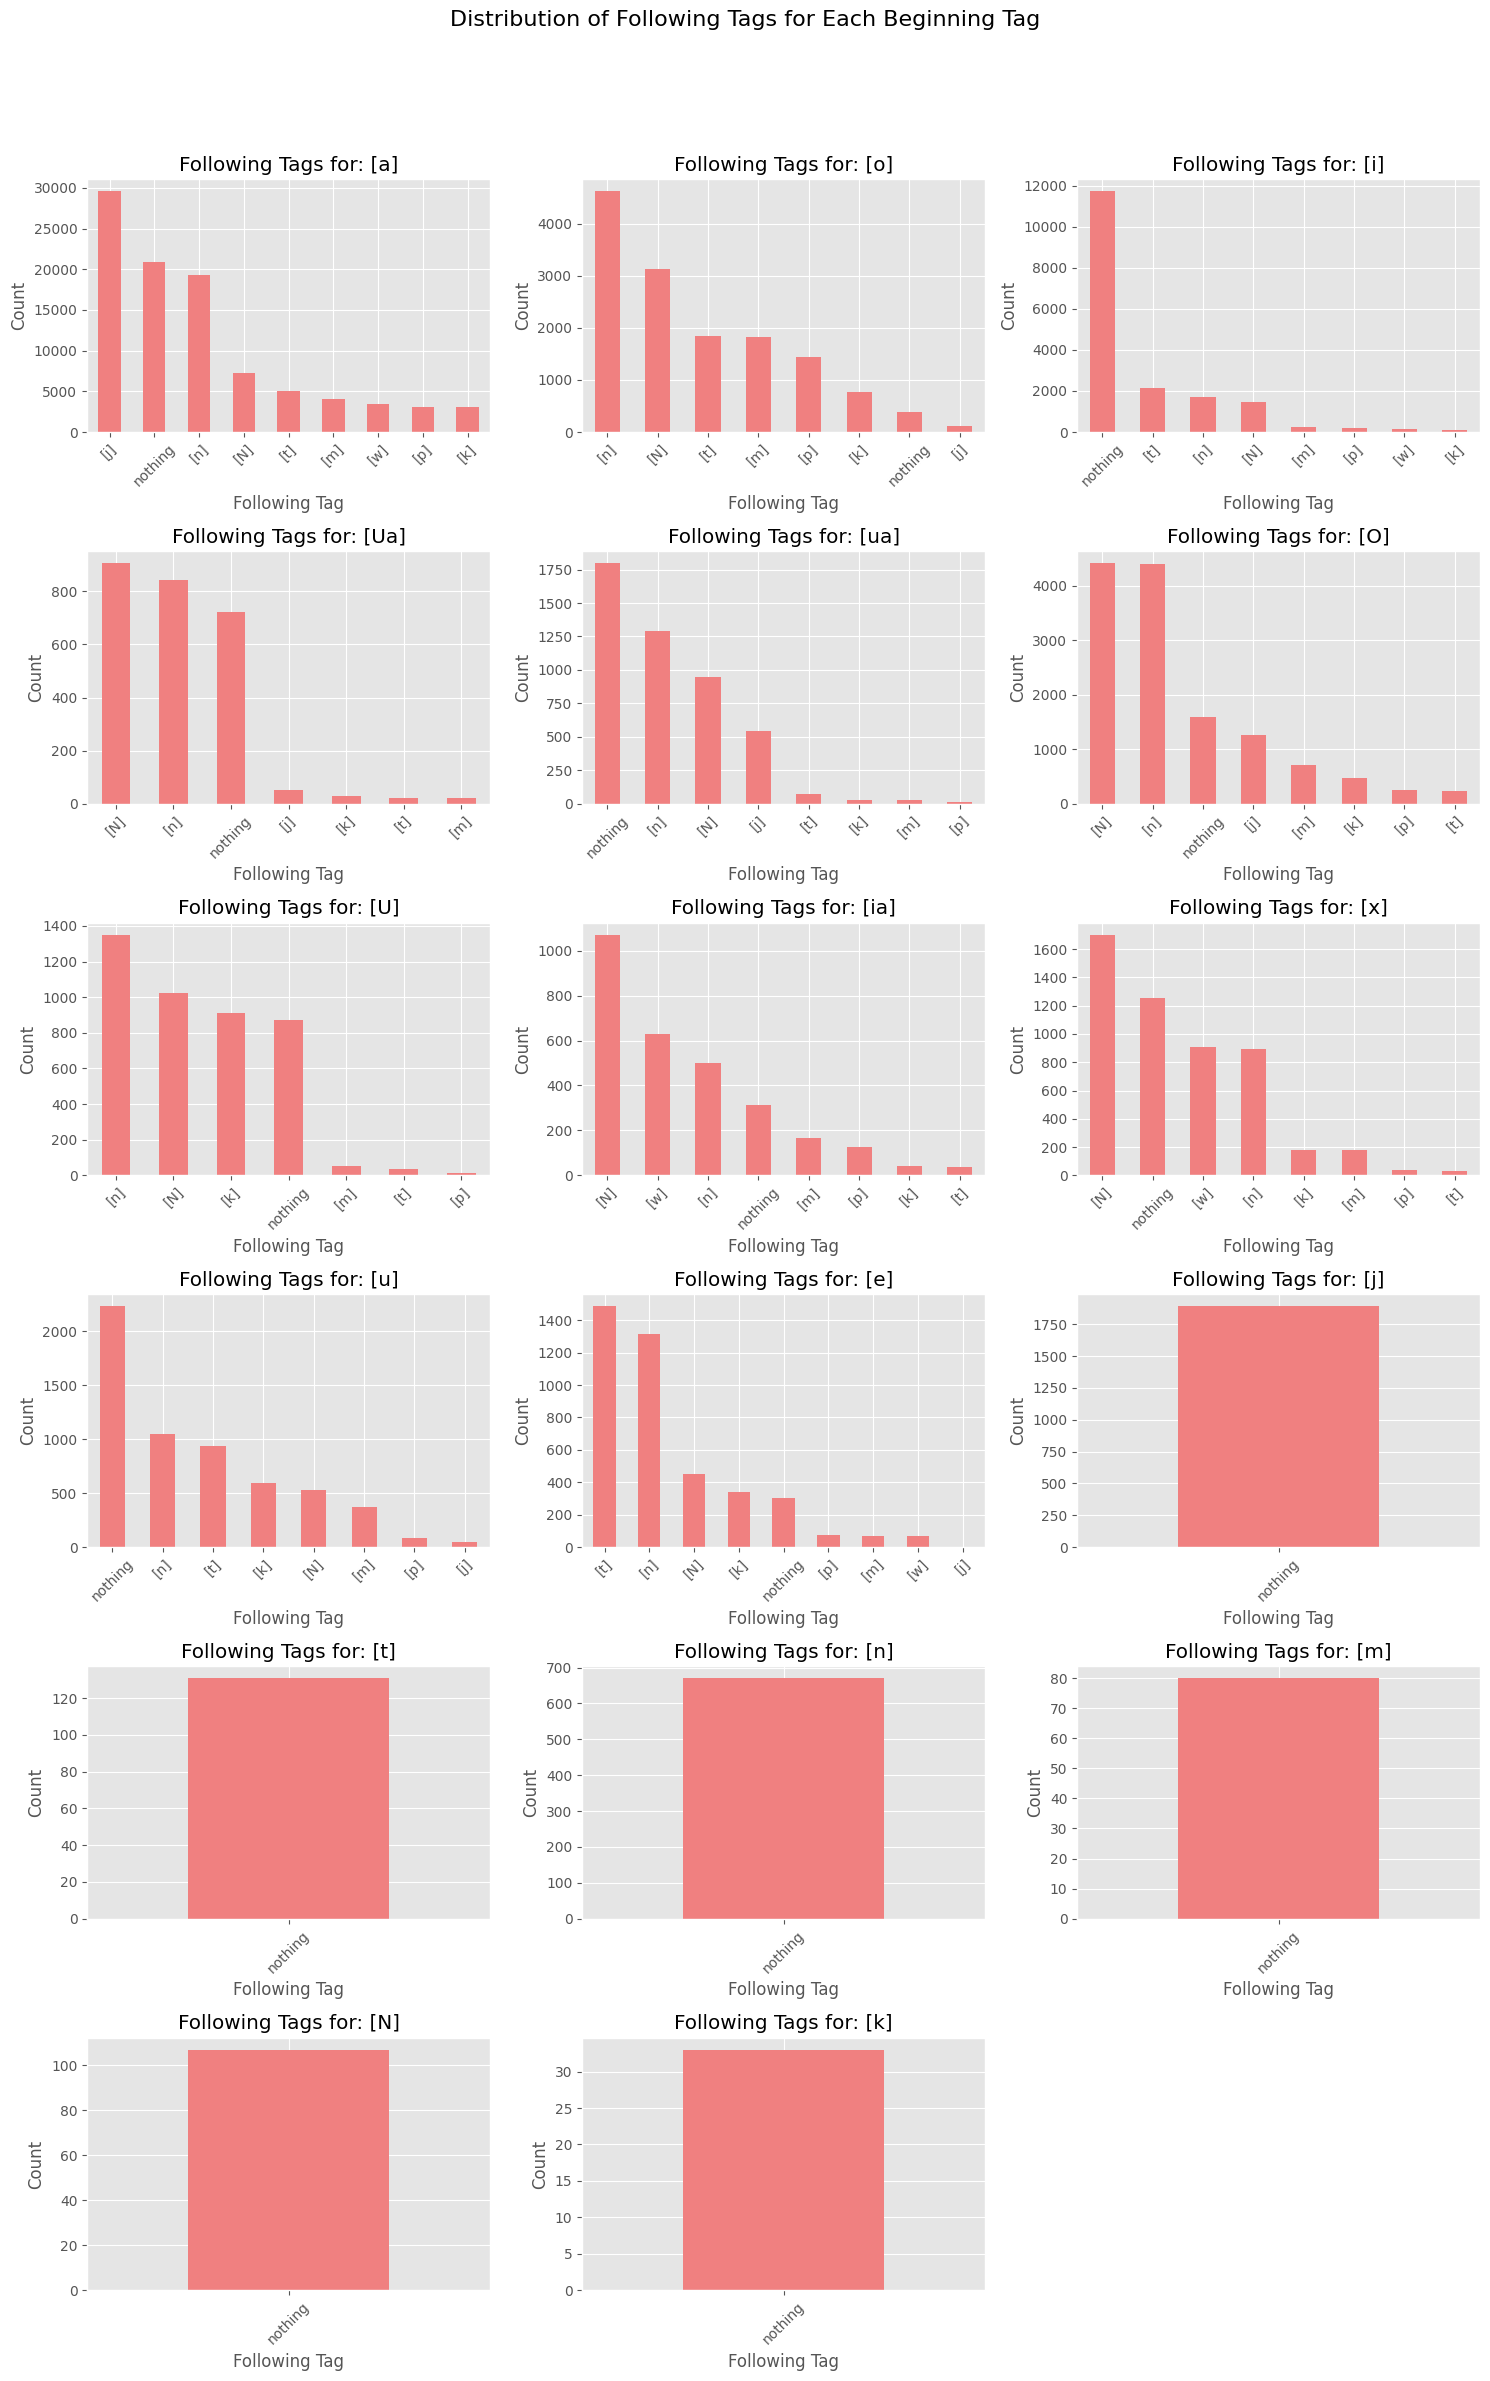

In [250]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Data Transformation ---
records = []
if result:
    for beginning_tag, following_dict in result.items():
        for following_tag, count in following_dict.items():
            records.append({
                'BeginningTag': beginning_tag,
                'FollowingTag': following_tag,
                'Count': count
            })

df = pd.DataFrame(records)

# --- Visualization ---

# 1. Overall Beginning Tag Frequency
if not df.empty:
    plt.style.use('ggplot')  # Using a style for better visuals

    overall_freq = df.groupby('BeginningTag')[
        'Count'].sum().sort_values(ascending=False)

    plt.figure(figsize=(12, 6))
    overall_freq.plot(kind='bar', color='skyblue')
    plt.title('Overall Frequency of Beginning Tags')
    plt.xlabel('Beginning Tag')
    plt.ylabel('Total Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # 2. Following Tag Distribution per Beginning Tag
    unique_beginning_tags = df['BeginningTag'].unique()
    # Determine grid size for subplots
    n_tags = len(unique_beginning_tags)
    n_cols = 3  # Adjust as needed
    n_rows = (n_tags + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(
        5 * n_cols, 4 * n_rows), sharey=False)
    axes = axes.flatten()  # Flatten to easily iterate

    for i, tag in enumerate(unique_beginning_tags):
        subset = df[df['BeginningTag'] == tag].sort_values(
            'Count', ascending=False)
        ax = axes[i]
        subset.plot(kind='bar', x='FollowingTag', y='Count',
                    ax=ax, legend=False, color='lightcoral')
        ax.set_title(f'Following Tags for: {tag}')
        ax.set_xlabel('Following Tag')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(
        'Distribution of Following Tags for Each Beginning Tag', fontsize=16, y=1.02)
    # Adjust layout to prevent title overlap
    plt.tight_layout(rect=[0, 0.03, 1, 0.98])
    plt.show()

else:
    print("DataFrame is empty. Cannot generate plots.")

In [209]:
from random import random

# Sample result
length_result = len(result)
for i in range(3):
    random_index = int(random() * length_result)
    print(result[random_index])

<klon8> จงหมายสั่งตั้งพิธีอภิ<r>[e][k]เษก</r>	กับองค์<r>[e][k]เอก</r>อัคเรศตามเพท<r>[a][j]ไสย</r>
มีเยี่ยงอย่างปางก่อนประการ<r>[a][j]ใด</r>	เสนา<r>[a][j]ใน</r>รีบรัดไปจัด<r>[x][N]แจง</r>
ให้สำเร็จเจ็ดค่ำเป็นกำ<r>[o][t]หนด</r>	ชน<r>[o][t]บท</r>บอกทั่วทุกรั้ว<r>[x][N]แขวง</r>
มีการเล่นเต้นรำนอกกำ<r>[x][N]แพง</r>	ตามตำ<r>[x][N]แหน่ง</r>น้อยใหญ่เร่งไคล<r>[a]คลา</r>

<klon8> แล้วตีสายถวายสมเด็จ<r>[a]พระ</r>	บรม<r>[a]รา</r>ชินีศรีส<r>[a][m]ยาม</r>
ขอพระราชานุญาตประกาศ<r>[a][m]นาม</r>	ตั้งเป็น<r>[a][m]ง่าม</r>แง่สภาอุณา<r>[o][m]โลม</r>
โปรดประทานโทรเลขภิเษก<r>[i]ศรี</r>	พระเสาว<r>[i]นีย์</r>ทะนุช่วยอำนวย<r>[o][m]โฉม</r>
มีต้นทุนหนุนอุดไม่ทรุด<r>[o][m]โทรม</r>	ทรงพระ<r>โ</r>สมนัสรับประคับประ<r>[O][N]คอง</r>
เงินเรี่ยได้ที่แพร่แลสัง<r>[e][t]เกต</r>	สองพัน<r>[e][t]เศษ</r>บาทได้บ้างให้<r>[O][N]ของ</r>
มีเสื่ออ่อนหมอนม้าผ้าปู<r>[O][N]รอง</r>	ที่ขัด<r>[O][N]ข้อง</r>เข้าช่วยเอาด้วย<r>[x][N]แรง</r>
โมทนาสถาผลกุศล<r>[ua][j]ช่วย</r>	ทั้งไข้<r>[ua][j]ป่วย</r>สิ้นไปอย่าได้<r>[x][N]แหนง</r>
ทานมัยให้ผลดล<

In [ ]:
data_not_a_sum = 0

for data in training_data:
    if not "[a]" in data and not "<phonetic>" in data:
        print(data)
        data_not_a_sum += 1

<klon8> กุมาราว่าดูเอาเจ้าแม่<r>[@][j]เอ๋ย</r>	กระไร<r>[@][j]เลย</r>ใจจิตผิดผู้<r>[i][N]หญิง</r>
ฉวยกระชากจากนางแล้วขว้าง<r>[i][N]ทิ้ง</r>	แค้น<r>[i][N]จริง</r>จริงใจคอใช่พอ<r>[i]ดี</r>
พระบิดาให้ถามดูตาม<r>[U]ซื่อ</r>	ควรแล้ว<r>[U]หรือ</r>แม่จะตายให้อาย<r>[i]ผี</r>
ถึงมาดแม้นแค้นบิดาไม่ปรา<r>[i]นี</r>	ลูกยัง<r>[i]มี</r>แม่ก็ไม่อาลัย<r>[@][j]เลย</r>

<klon8> ฝูงมฤคถึกเถื่อนเที่ยวเกลื่อน<r>[u][m]กลุ้ม</r>	เป็นคู่<r>[u][m]คุม</r>เคียงนางไม่ห่าง<r>[@][n]เหิน</r>
เห็นกวางทองย่องเยื้องชำเลือง<r>[@][n]เดิน</r>	เหมือนน้อง<r>[@][n]เชิญ</r>พานผ้าประหม่า<r>[ia][N]เมียง</r>
พี่เข้าด้วยช่วยประคองพระน้อง<r>[u][t]นุช</r>	สงสาร<r>[u][t]สุด</r>สุดสวาทไม่อาจ<r>[ia][N]เถียง</r>
โอ้ยามนี้มิได้น้องประคอง<r>[ia][N]เคียง</r>	พี่ก็<r>[ia][N]เสี่ยง</r>บุญตามเจ้าทราม<r>[@][j]เชย</r>
เป็นกุศลหนหลังเราทั้ง<r>[O][N]สอง</r>	คงได้<r>[O][N]น้อง</r>คืนมาเรียงเคียง<r>[@][j]เขนย</r>
แม้นกรรมหนุนบุญน้อยจะลอย<r>[@][j]เลย</r>	มิได้<r>[@][j]เชย</r>บุษบาพะงา<r>[O][n]งอน</r>

<klon8> หรือห่วงหลังหวังรักไปนัค<r>[e][t]เรศ</r>	

In [168]:
data_not_a_sum

119

In [77]:
phonetic_token[:10]

['<phonetic>',
 '<rom>',
 '<th>',
 '[0]',
 '[1]',
 '[2]',
 '[3]',
 '[4]',
 '[?]',
 '[@@]']

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "scb10x/llama3.2-typhoon2-1b", token="paste-your-huggingface-token-here")

In [5]:
text_example = training_data[0]
text_example

'<klon8> พอได้ยินเสียงระฆังข้างหลัง<r>[a][w]เขา</r>\tเห็นผู้<r>[a][w]เฒ่า</r>ออกจากชะวาก<r>[a]ผา</r>\nดูสรรพางค์ร่างกายแก่ช<r>[a]รา</r>\tแต่ผิว<r>[a]หน้า</r>นั้นละม้ายคล้ายทา<r>[o][k]รก</r>\nทรงเสื้อโขมพัสตรานุ่งผ้า<r>[a][w]ขาว</r>\tผมนั้น<r>[a][w]ยาว</r>ย้อยสยายประปราย<r>[o][k]ปรก</r>\nถือไม้เท้าเนาวรัตน์พัดขน<r>[o][k]นก</r>\tทำเดิน<r>[o][k]งก</r>งันมาแล้วพา<r>[i]ที</r>\nว่าดูราสามีนางผี<r>[Ua]เสื้อ</r>\tเป็นหน่อ<r>[Ua]เนื้อ</r>กษัตริย์ชาติราช<r>[i]สีห์</r>\nอย่าเผาศพนางยักษ์ด้วยอัค<r>[i]คี</r>\tภัยจะ<r>[i]มี</r>ถึงกายให้วาย<r>[a][n]ปราณ</r>\n'

### Before add phonetic token

In [23]:
tokenized_example = tokenizer.encode(text_example, add_special_tokens=False)

In [24]:
len(tokenized_example)

326

In [25]:
print(tokenizer.decode(tokenized_example))

<klon8> พอได้ยินเสียงระฆังข้างหลัง<r>[a][w]เขา</r>	เห็นผู้<r>[a][w]เฒ่า</r>ออกจากชะวาก<r>[a]ผา</r>
ดูสรรพางค์ร่างกายแก่ช<r>[a]รา</r>	แต่ผิว<r>[a]หน้า</r>นั้นละม้ายคล้ายทา<r>[o][k]รก</r>
ทรงเสื้อโขมพัสตรานุ่งผ้า<r>[a][w]ขาว</r>	ผมนั้น<r>[a][w]ยาว</r>ย้อยสยายประปราย<r>[o][k]ปรก</r>
ถือไม้เท้าเนาวรัตน์พัดขน<r>[o][k]นก</r>	ทำเดิน<r>[o][k]งก</r>งันมาแล้วพา<r>[i]ที</r>
ว่าดูราสามีนางผี<r>[Ua]เสื้อ</r>	เป็นหน่อ<r>[Ua]เนื้อ</r>กษัตริย์ชาติราช<r>[i]สีห์</r>
อย่าเผาศพนางยักษ์ด้วยอัค<r>[i]คี</r>	ภัยจะ<r>[i]มี</r>ถึงกายให้วาย<r>[a][n]ปราณ</r>



### After add phonetic token

In [132]:
num_added_tokens = tokenizer.add_tokens(phonetic_token, special_tokens=True)

print(f"Added {num_added_tokens} new tokens to the tokenizer")

Added 65 new tokens to the tokenizer


In [133]:
print(tokenizer.tokenize(text_example))

['<klon8>', 'Ġà¸ŀ', 'à¸Ń', 'à¹Ħà¸Ķ', 'à¹īà¸¢', 'à¸´à¸Ļ', 'à¹Ģà¸ª', 'à¸µà¸¢à¸ĩ', 'à¸£à¸°', 'à¸Ĩ', 'à¸±à¸ĩ', 'à¸Ĥ', 'à¹īà¸²à¸ĩ', 'à¸«à¸¥', 'à¸±à¸ĩ', '<r>', '[a]', '[w]', 'à¹Ģà¸Ĥà¸²', '</r>', 'ĉ', 'à¹Ģà¸«', 'à¹ĩà¸Ļà¸ľ', 'à¸¹à¹ī', '<r>', '[a]', '[w]', 'à¹Ģà¸', 'Ĵ', 'à¹Īà¸²', '</r>', 'à¸Ńà¸Ńà¸ģ', 'à¸Īà¸²à¸ģ', 'à¸Ĭ', 'à¸°', 'à¸§', 'à¸²à¸ģ', '<r>', '[a]', 'à¸ľ', 'à¸²', '</r>', 'Ċ', 'à¸Ķ', 'à¸¹', 'à¸ªà¸£', 'à¸£', 'à¸ŀ', 'à¸²à¸ĩ', 'à¸Ħ', 'à¹Įà¸£', 'à¹Īà¸²à¸ĩà¸ģ', 'à¸²à¸¢', 'à¹ģà¸ģ', 'à¹Ī', 'à¸Ĭ', '<r>', '[a]', 'à¸£', 'à¸²', '</r>', 'ĉ', 'à¹ģà¸ķ', 'à¹Ī', 'à¸ľ', 'à¸´à¸§', '<r>', '[a]', 'à¸«à¸Ļ', 'à¹īà¸²', '</r>', 'à¸Ļ', 'à¸±à¹ī', 'à¸Ļ', 'à¸¥à¸°', 'à¸¡', 'à¹īà¸²à¸¢', 'à¸Ħà¸¥', 'à¹īà¸²à¸¢', 'à¸Ĺ', 'à¸²', '<r>', '[o]', '[k]', 'à¸£à¸ģ', '</r>', 'Ċ', 'à¸Ĺà¸£à¸ĩ', 'à¹Ģà¸ª', 'à¸·à¹ī', 'à¸Ń', 'à¹Ĥ', 'à¸Ĥ', 'à¸¡', 'à¸ŀ', 'à¸±à¸ª', 'à¸ķà¸£', 'à¸²à¸Ļ', 'à¸¸à¹Ī', 'à¸ĩ', 'à¸ľ', 'à¹īà¸²', '<r>', '[a]', '[w]', 'à¸Ĥ', 'à¸²à¸§', '</r>', 'ĉ', 'à¸ľ', 'à¸¡à¸Ļ', 'à¸±à¹ī', 'à¸Ļ', '<r>', '[a]', '[w]', 'à¸¢à¸²à¸§', '</r

In [4]:
# Count the number of tokens in the training data
num_tokens = 0
max_tokens = 0

for text in raw_training_data:
    tokens = tokenizer.tokenize(text)
    num_tokens += len(tokens)
    max_tokens = max(max_tokens, len(tokens))
print(f"Number of tokens in training data: {num_tokens}")
print(f"Max number of tokens in a single text: {max_tokens}")

Number of tokens in training data: 1748297
Max number of tokens in a single text: 25133


In [5]:
# Count the number of tokens in the training data
num_tokens = 0
max_tokens = 0

for text in raw_validation_data:
    tokens = tokenizer.tokenize(text)
    num_tokens += len(tokens)
    max_tokens = max(max_tokens, len(tokens))
print(f"Number of tokens in training data: {num_tokens}")
print(f"Max number of tokens in a single text: {max_tokens}")

Number of tokens in training data: 190601
Max number of tokens in a single text: 2288


In [85]:
tokenizer.tokenize("<start_of_turn>")

['<start_of_turn>']

In [86]:
from collections import defaultdict
import re

pattern = r'<r>(.+?)</r>'

matches = re.findall(pattern, "<klon8> พอได้ยินเสียงระฆังข้างหลัง<r>[a][w]เขา</r>\tเห็นผู้<r>[a][w]เฒ่า</r>")

tag_dict = defaultdict(set)

for item in matches:
    # Extract all tags (e.g., [a], [w])
    tags = re.findall(r'\[.*?\]', item)
    # Extract the word by removing tags
    word = re.sub(r'\[.*?\]', '', item).strip()
    # Add the word to each tag's set
    for tag in tags:
        tag_dict[tag].add(word)

tag_dict

defaultdict(set, {'[a]': {'เขา', 'เฒ่า'}, '[w]': {'เขา', 'เฒ่า'}})

In [87]:
def extract_phonetic_combinations(training_data, tokenizer):
    # Define regex pattern to match <r>[X][Y]text</r> patterns
    pattern = r'<r>(.+?)</r>'

    tag_dict = defaultdict(set)

    # Process each text in the training data
    for text in training_data:
        # Find all matches of the pattern in the text
        matches = re.findall(pattern, text)

        for item in matches:
            # Extract all tags (e.g., [a], [w])
            tags = re.findall(r'\[.*?\]', item)
            # Extract the word by removing tags
            word = re.sub(r'\[.*?\]', '', item).strip()
            # Add the word to each tag's set
            for tag in tags:
                if "<r>" in word:
                    print(f"Warning: <r> tag found in word '{word}'. Skipping this entry.")
                    continue
                tag_dict[tag].add(word)
                
    new_tag_dict = defaultdict(set)
    for key, value in tag_dict.items():
        for word in value:
            tokenized_words = tokenizer.encode(word, add_special_tokens=False)
            if "<r>" in tokenized_words:
                print(f"Value: {value}")
                print(f"Tokenized word: {word}")
                print(f"Tokenized word: {tokenized_words}")
            for tokenized_word in tokenized_words:
                new_tag_dict[key].add(tokenized_word)
                
    return new_tag_dict

In [88]:
tag_dict = extract_phonetic_combinations(training_data, tokenizer)
tag_dict

defaultdict(set,
            {'[a]': {4656,
              4791,
              4956,
              5574,
              6304,
              7031,
              7375,
              7831,
              7916,
              8048,
              8100,
              8533,
              9210,
              9532,
              10074,
              10126,
              10335,
              10793,
              11053,
              11331,
              11623,
              11718,
              12667,
              12925,
              13274,
              14184,
              14263,
              14414,
              14747,
              14899,
              15079,
              15222,
              15900,
              16211,
              16250,
              16278,
              16434,
              16634,
              17889,
              18247,
              18351,
              19030,
              19098,
              19266,
              19785,
              20237,
              20281,
   

In [89]:
tokenizer.encode("เขา", add_special_tokens=False)

[59643]

In [90]:
tokenizer.convert_ids_to_tokens(1)

'<eos>'

In [62]:
len(tag_dict["[a]"])

511

In [92]:
list(tag_dict.keys())

['[a]',
 '[w]',
 '[o]',
 '[k]',
 '[i]',
 '[Ua]',
 '[n]',
 '[j]',
 '[ua]',
 '[N]',
 '[O]',
 '[U]',
 '[ia]',
 '[t]',
 '[x]',
 '[m]',
 '[u]',
 '[e]',
 '[@]',
 '[p]']

In [94]:
list(tag_dict.keys())

['[a]',
 '[w]',
 '[o]',
 '[k]',
 '[i]',
 '[Ua]',
 '[n]',
 '[j]',
 '[ua]',
 '[N]',
 '[O]',
 '[U]',
 '[ia]',
 '[t]',
 '[x]',
 '[m]',
 '[u]',
 '[e]',
 '[@]',
 '[p]']

In [ ]:
tokenizer.encode('[o]', add_special_tokens=False)

[262185]

In [1]:
import json
from utils.file_utils import get_data_from_json

In [2]:
training_data = get_data_from_json("dataset/training_data.json")
training_data[:3]

['<klon8> พอได้ยินเสียงระฆังข้างหลัง<r>[a][w]เขา</r>\tเห็นผู้<r>[a][w]เฒ่า</r>ออกจากชะวาก<r>[a]ผา</r>\nดูสรรพางค์ร่างกายแก่ช<r>[a]รา</r>\tแต่ผิว<r>[a]หน้า</r>นั้นละม้ายคล้ายทา<r>[o][k]รก</r>\nทรงเสื้อโขมพัสตรานุ่งผ้า<r>[a][w]ขาว</r>\tผมนั้น<r>[a][w]ยาว</r>ย้อยสยายประปราย<r>[o][k]ปรก</r>\nถือไม้เท้าเนาวรัตน์พัดขน<r>[o][k]นก</r>\tทำเดิน<r>[o][k]งก</r>งันมาแล้วพา<r>[i]ที</r>\nว่าดูราสามีนางผี<r>[Ua]เสื้อ</r>\tเป็นหน่อ<r>[Ua]เนื้อ</r>กษัตริย์ชาติราช<r>[i]สีห์</r>\nอย่าเผาศพนางยักษ์ด้วยอัค<r>[i]คี</r>\tภัยจะ<r>[i]มี</r>ถึงกายให้วาย<r>[a][n]ปราณ</r>\n',
 '<klon8> ฝ่ายครุฑเที่ยวเล่นในหิม<r>[a][n]วันต์</r>\tสุริยาสา<r>[a][n]ยัณห์</r>ก็ผัน<r>[a][j]ผาย</r>\nสู่สถานวิมานรัตน์พรรณ<r>[a][j]ราย</r>\tก็<r>[a][j]ร่าย</r>เวทเปิดทวารเข้าไพช<r>[o][n]ยนต์</r>\nนั่งแนบแอบแก้วกานดา<r>[ua][N]ดวง</r>\tแล้วยื่น<r>[ua][N]พวง</r>อัมพาผลา<r>[o][n]ผล</r>\nกินเล่นให้สำราญบานก<r>[o][n]มล</r>\tพลางยิ้มแย้มแกม<r>[o][n]กล</r>ให้ยั่ว<r>[ua][n]ยวน</r>\nร่วมภิรมย์สมสมัครดั่งใจ<r>[O][N]ปอง</r>\tระเริงริกซิก<r>[O][N]สอง</r>

In [3]:
mock_data = []

for data in training_data[:10]:
    input_data = data.split("<r>")[0].strip()
    new_data = {
        "input": input_data,
        "output": data
    }
    mock_data.append(new_data)

In [13]:
with open("test_result/mock_data.json", "w", encoding="utf-8") as f:
    json.dump(mock_data, f, ensure_ascii=False, indent=4)

In [5]:
for data in mock_data:
    print("Output: ", data["output"])
    print()

Output:  <klon8> พอได้ยินเสียงระฆังข้างหลัง<r>[a][w]เขา</r>	เห็นผู้<r>[a][w]เฒ่า</r>ออกจากชะวาก<r>[a]ผา</r>
ดูสรรพางค์ร่างกายแก่ช<r>[a]รา</r>	แต่ผิว<r>[a]หน้า</r>นั้นละม้ายคล้ายทา<r>[o][k]รก</r>
ทรงเสื้อโขมพัสตรานุ่งผ้า<r>[a][w]ขาว</r>	ผมนั้น<r>[a][w]ยาว</r>ย้อยสยายประปราย<r>[o][k]ปรก</r>
ถือไม้เท้าเนาวรัตน์พัดขน<r>[o][k]นก</r>	ทำเดิน<r>[o][k]งก</r>งันมาแล้วพา<r>[i]ที</r>
ว่าดูราสามีนางผี<r>[Ua]เสื้อ</r>	เป็นหน่อ<r>[Ua]เนื้อ</r>กษัตริย์ชาติราช<r>[i]สีห์</r>
อย่าเผาศพนางยักษ์ด้วยอัค<r>[i]คี</r>	ภัยจะ<r>[i]มี</r>ถึงกายให้วาย<r>[a][n]ปราณ</r>


Output:  <klon8> ฝ่ายครุฑเที่ยวเล่นในหิม<r>[a][n]วันต์</r>	สุริยาสา<r>[a][n]ยัณห์</r>ก็ผัน<r>[a][j]ผาย</r>
สู่สถานวิมานรัตน์พรรณ<r>[a][j]ราย</r>	ก็<r>[a][j]ร่าย</r>เวทเปิดทวารเข้าไพช<r>[o][n]ยนต์</r>
นั่งแนบแอบแก้วกานดา<r>[ua][N]ดวง</r>	แล้วยื่น<r>[ua][N]พวง</r>อัมพาผลา<r>[o][n]ผล</r>
กินเล่นให้สำราญบานก<r>[o][n]มล</r>	พลางยิ้มแย้มแกม<r>[o][n]กล</r>ให้ยั่ว<r>[ua][n]ยวน</r>
ร่วมภิรมย์สมสมัครดั่งใจ<r>[O][N]ปอง</r>	ระเริงริกซิก<r>[O][N]สอง</r>เกษม<r>[